In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# !export PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT=2

### Load packages and data

In [ ]:
import spatialdata_io
import matplotlib.pyplot as plt
import spatialdata as sd
import segtraq
import spatialdata_plot
import scanpy as sc
import seaborn as sns
import anndata as ad
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import dask.dataframe as dd
import glob
from dask import delayed

from spatialdata.models import PointsModel
import statsmodels.api as sm
from pathlib import Path
from spatialdata.transformations import (
    get_transformation,
    set_transformation,
)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sdata = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr/")


In [4]:
st = segtraq.SegTraQ(
    sdata,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


In [5]:
%%time
st.run_baseline()

CPU times: user 1.38 s, sys: 243 ms, total: 1.63 s
Wall time: 1.71 s


In [6]:
%%time
# recompute region similarity
st.rs.similarity_border_neighborhood()

CPU times: user 1min 27s, sys: 491 ms, total: 1min 28s
Wall time: 1min 29s


,cell_id,similarity_center_border,similarity_border_neighborhood,ratio_border_neighborhood_to_center
0,6327,0.527484,0.599392,1.136323
1,6328,0.505440,0.491721,0.972858
2,6330,0.448379,0.509950,1.137320
3,6331,0.538128,0.620968,1.153941
4,6332,0.549761,0.586564,1.066943
...,...,...,...,...
1557,95953,0.498089,0.531000,1.066074
1558,95954,0.255608,0.404242,1.581491
1559,95955,0.390033,0.393295,1.008362
1560,95959,0.412926,0.345856,0.837574


In [7]:
st.sdata['table']

AnnData object with n_obs × n_vars = 1563 × 313
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'nucleus_area', 'region', 'centroid_x', 'centroid_y', 'gene_count', 'mean_transcripts_per_gene', 'transcript_count', 'transcript_density', 'cell_area', 'perimeter', 'circularity', 'bbox_width', 'bbox_height', 'extent', 'solidity', 'convexity', 'elongation', 'eccentricity', 'compactness', 'num_polygons', 'similarity_center_border', 'similarity_border_neighborhood', 'ratio_border_neighborhood_to_center'
    var: 'gene_ids', 'feature_types', 'genome', 'total', 'unassigned', 'perc_unassigned'
    uns: 'spatialdata_attrs', 'num_cells', 'num_transcripts', 'num_genes', 'perc_unassigned_transcripts'
    obsm: 'spatial'

In [8]:
features = ['similarity_center_border', 'similarity_border_neighborhood', 'ratio_border_neighborhood_to_center', 'transcript_count']
cell_df = []
obs = sdata.tables['table'].obs[features].copy()
obs['sample'] = "proseg2"
cell_df.append(obs)
cell_df = pd.concat(cell_df)
print(cell_df.shape)
cell_df = cell_df.reset_index(drop=True)
cell_df.head()

(1563, 5)


,similarity_center_border,similarity_border_neighborhood,ratio_border_neighborhood_to_center,transcript_count,sample
0,0.527484,0.599392,1.136323,420.0,proseg2
1,0.505440,0.491721,0.972858,201.0,proseg2
2,0.448379,0.509950,1.137320,391.0,proseg2
3,0.538128,0.620968,1.153941,512.0,proseg2
4,0.549761,0.586564,1.066943,345.0,proseg2


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

def plot_rs_against_counts(cell_df, xcol, ycols):
    plot_df = cell_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[xcol] + ycols)
    plot_df = plot_df[plot_df[xcol] >= 0]

    n_cols = min(3, len(ycols))
    n_rows = int(np.ceil(len(ycols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        sharex=False,
        sharey=False
    )

    # make axes always 2D
    axes = np.atleast_2d(axes)

    for j, ycol in enumerate(ycols):
        i, k = divmod(j, n_cols)
        ax = axes[i, k]

        sns.scatterplot(
            data=plot_df,
            x=xcol,
            y=ycol,
            alpha=0.25,
            s=10,
            linewidth=0,
            ax=ax,
            color="black"
        )

        X = sm.add_constant(plot_df[xcol].to_numpy())
        y = plot_df[ycol].to_numpy()

        if len(X) > 1:
            model = sm.OLS(y, X, missing="drop").fit()
            r2 = model.rsquared

            xs = np.linspace(plot_df[xcol].min(), plot_df[xcol].max(), 200)
            ys = model.predict(sm.add_constant(xs))

            ax.plot(xs, ys, color="red")
            title = f"{ycol}\n$R^2$={r2:.3f}"
        else:
            title = ycol

        ax.set_title(title)

        if i == n_rows - 1:
            ax.set_xlabel(xcol)
        else:
            ax.set_xlabel("")

    # hide unused axes
    total_axes = n_rows * n_cols
    for j in range(len(ycols), total_axes):
        i, k = divmod(j, n_cols)
        axes[i, k].set_visible(False)

    plt.tight_layout()
    plt.show()

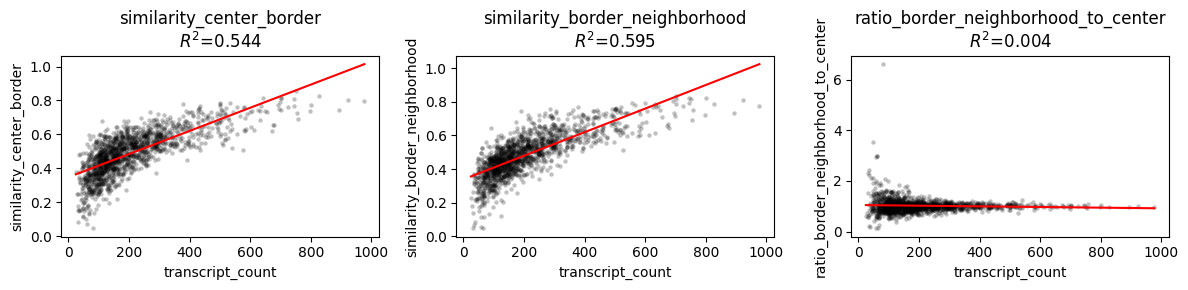

In [10]:
plot_rs_against_counts(cell_df, "transcript_count",
                       ycols=[
                        "similarity_center_border",
                        "similarity_border_neighborhood",
                        "ratio_border_neighborhood_to_center",
                    ])

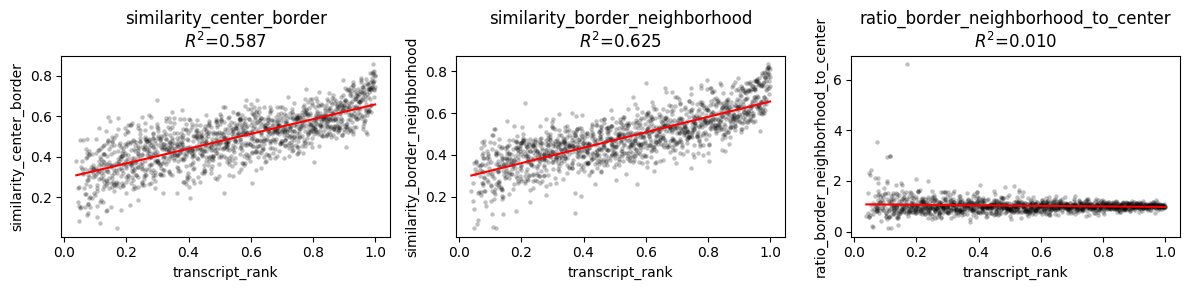

In [11]:
cell_df["transcript_rank"] = cell_df["transcript_count"].rank(pct=True)
plot_rs_against_counts(cell_df, "transcript_rank",
                        ycols=[
                        "similarity_center_border",
                        "similarity_border_neighborhood",
                        "ratio_border_neighborhood_to_center",
                    ])

In [12]:
st.rs.null_corrected_center_border_similarity(n_sim=200)

,similarity_center_border,similarity_center_border_null_mean,similarity_center_border_null_sd,similarity_center_border_residual,similarity_center_border_zscore,similarity_border_neighborhood,similarity_border_neighborhood_null_mean,similarity_border_neighborhood_null_sd,similarity_border_neighborhood_residual,similarity_border_neighborhood_zscore,contamination_score,center_counts_used,border_counts_used,neighborhood_counts_used,n_genes_used,cell_id
0,0.527484,0.677307,0.027165,-0.149823,-5.515292,0.599392,0.632167,0.026410,-0.032775,-1.240998,0.117048,288,125,630,167,6327
1,0.505440,0.533815,0.033173,-0.028375,-0.855376,0.491721,0.554609,0.029030,-0.062888,-2.166349,-0.034513,125,72,484,144,6328
2,0.448379,0.573081,0.029794,-0.124703,-4.185456,0.509950,0.605730,0.028768,-0.095780,-3.329377,0.028923,271,107,380,151,6330
3,0.538128,0.659095,0.023359,-0.120966,-5.178485,0.620968,0.665188,0.022813,-0.044219,-1.938309,0.076747,344,152,896,186,6331
4,0.549761,0.599429,0.028580,-0.049669,-1.737880,0.586564,0.617863,0.023091,-0.031299,-1.355465,0.018369,227,109,715,178,6332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1557,0.498089,0.616906,0.033199,-0.118817,-3.578974,0.531000,0.618715,0.028732,-0.087716,-3.052910,0.031101,137,114,318,130,95953
1558,0.255608,0.339088,0.061410,-0.083480,-1.359377,0.404242,0.394794,0.039905,0.009448,0.236757,0.092927,58,18,357,119,95954
1559,0.390033,0.452667,0.056749,-0.062633,-1.103702,0.393295,0.435235,0.053980,-0.041940,-0.776947,0.020694,63,24,89,63,95955
1560,0.412926,0.398777,0.069044,0.014149,0.204925,0.345856,0.317715,0.046286,0.028141,0.607980,0.013992,49,15,162,96,95959


In [13]:
sdata.tables["table"].obs["contam_score_res"] = sdata.tables["table"].obs["similarity_border_neighborhood_residual"] - sdata.tables["table"].obs["similarity_center_border_residual"]

In [14]:
features = (['similarity_center_border', 
             'similarity_center_border_null_mean', 
             'similarity_center_border_null_sd', 
             'similarity_center_border_residual', 
             'similarity_center_border_zscore', 
             'similarity_border_neighborhood',
             'similarity_border_neighborhood_null_mean', 
             'similarity_border_neighborhood_null_sd', 
             'similarity_border_neighborhood_residual', 
             'similarity_border_neighborhood_zscore', 
             'contam_score_res',
             'contamination_score',
             'transcript_count'])
cell_df = []
obs = sdata.tables['table'].obs[features].copy()
obs['sample'] = "xenium"
cell_df.append(obs)
cell_df = pd.concat(cell_df)
print(cell_df.shape)
cell_df = cell_df.reset_index(drop=True)
cell_df.head()

(1563, 14)


,similarity_center_border,similarity_center_border_null_mean,similarity_center_border_null_sd,similarity_center_border_residual,similarity_center_border_zscore,similarity_border_neighborhood,similarity_border_neighborhood_null_mean,similarity_border_neighborhood_null_sd,similarity_border_neighborhood_residual,similarity_border_neighborhood_zscore,contam_score_res,contamination_score,transcript_count,sample
0,0.527484,0.677307,0.027165,-0.149823,-5.515292,0.599392,0.632167,0.026410,-0.032775,-1.240998,0.117048,0.117048,420.0,xenium
1,0.505440,0.533815,0.033173,-0.028375,-0.855376,0.491721,0.554609,0.029030,-0.062888,-2.166349,-0.034513,-0.034513,201.0,xenium
2,0.448379,0.573081,0.029794,-0.124703,-4.185456,0.509950,0.605730,0.028768,-0.095780,-3.329377,0.028923,0.028923,391.0,xenium
3,0.538128,0.659095,0.023359,-0.120966,-5.178485,0.620968,0.665188,0.022813,-0.044219,-1.938309,0.076747,0.076747,512.0,xenium
4,0.549761,0.599429,0.028580,-0.049669,-1.737880,0.586564,0.617863,0.023091,-0.031299,-1.355465,0.018369,0.018369,345.0,xenium


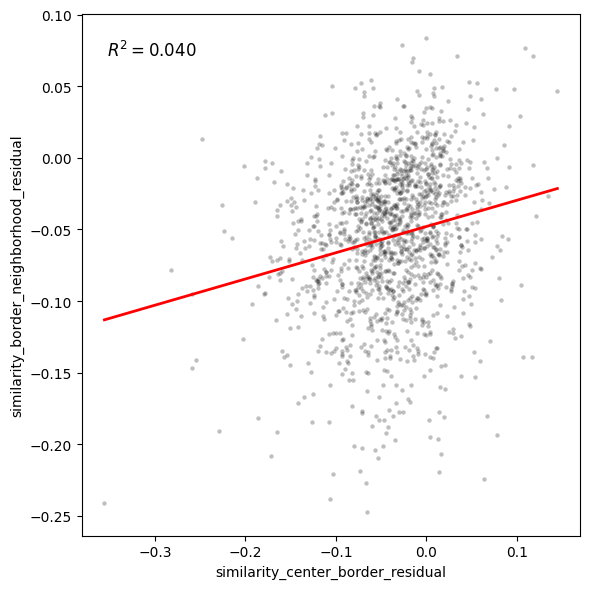

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

x_col = "similarity_center_border_residual"
y_col = "similarity_border_neighborhood_residual"

# drop missing values just in case
df_plot = cell_df[[x_col, y_col]].dropna()

x = df_plot[x_col]
y = df_plot[y_col]

# linear regression
res = linregress(x, y)
r2 = res.rvalue**2

plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_plot,
    x=x_col,
    y=y_col,
    alpha=0.25,
    s=10,
    linewidth=0,
    color="black"
)

sns.regplot(
    data=df_plot,
    x=x_col,
    y=y_col,
    scatter=False,
    ci=None,
    color="red",
    line_kws={"linewidth": 2}
)

# annotate R² on the plot
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.3f}$",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8)
)

plt.tight_layout()
plt.show()

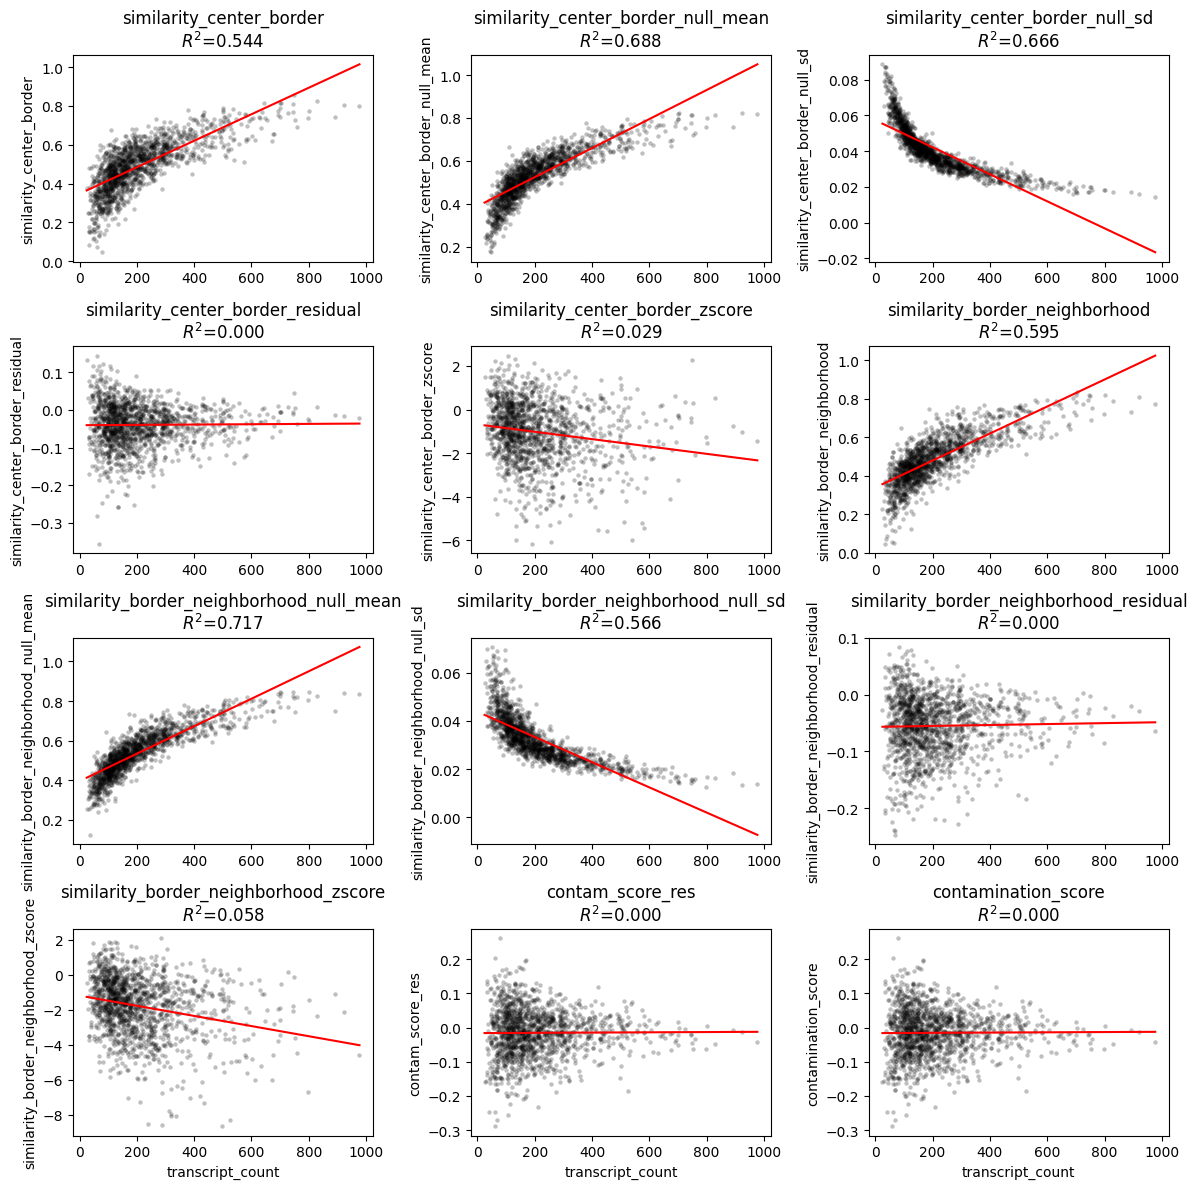

In [16]:
plt.style.use("default")
plot_rs_against_counts(cell_df, "transcript_count",
                       ycols=[
                        'similarity_center_border',
                        'similarity_center_border_null_mean', 
                        'similarity_center_border_null_sd', 
                        'similarity_center_border_residual', 
                        'similarity_center_border_zscore', 
                        'similarity_border_neighborhood',
                        'similarity_border_neighborhood_null_mean', 
                        'similarity_border_neighborhood_null_sd', 
                        'similarity_border_neighborhood_residual', 
                        'similarity_border_neighborhood_zscore', 
                        'contam_score_res',
                        'contamination_score'
                    ])

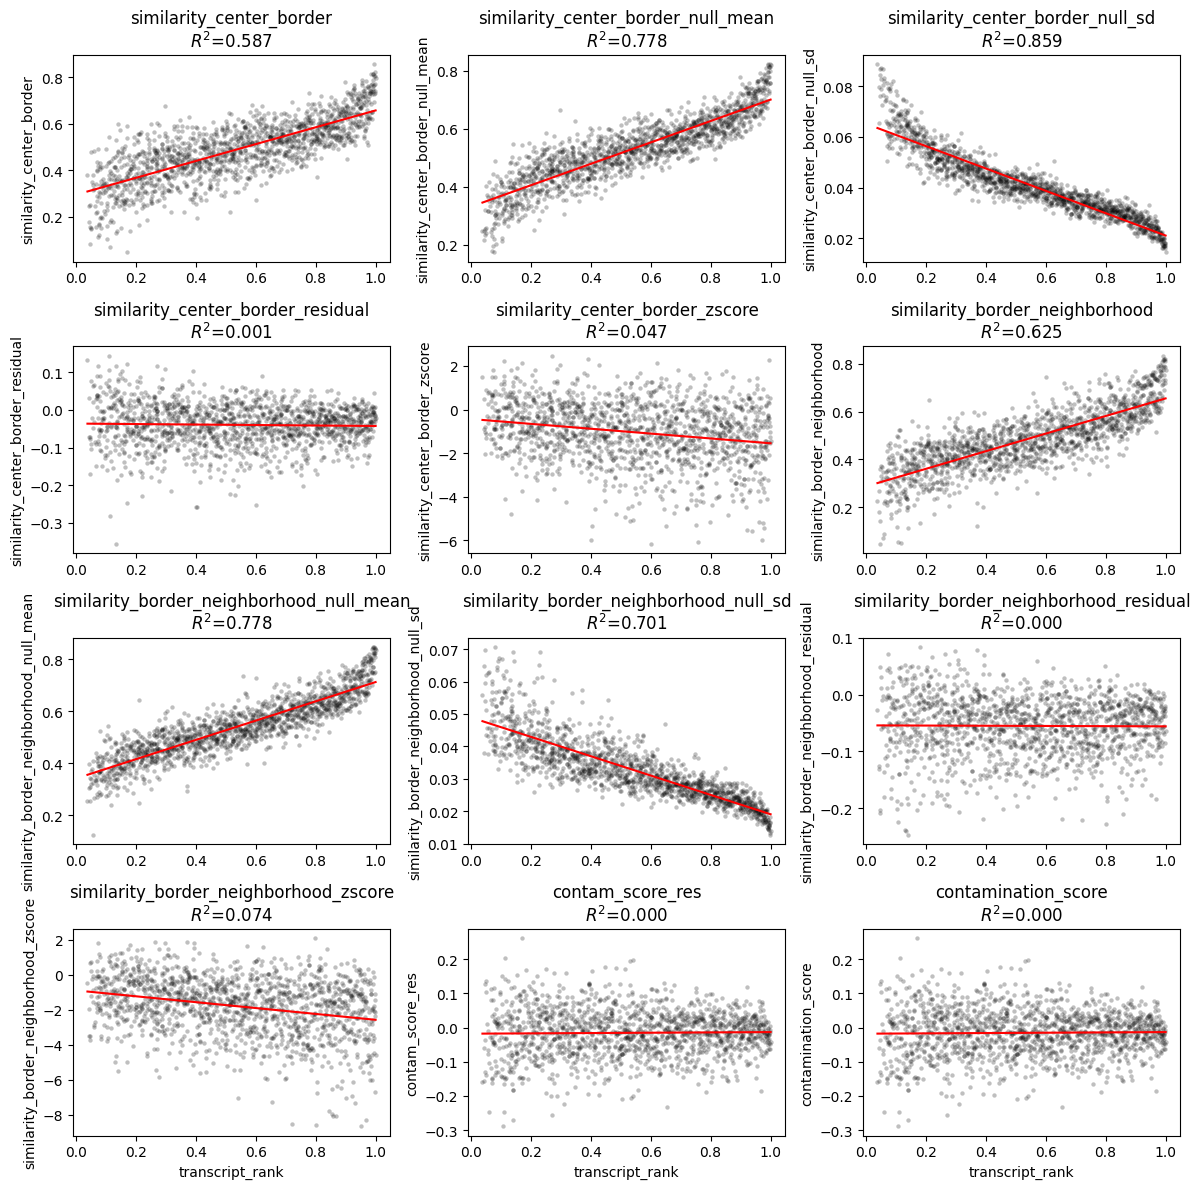

In [17]:
cell_df["transcript_rank"] = cell_df["transcript_count"].rank(pct=True)
plot_rs_against_counts(cell_df, "transcript_rank",
                       ycols=[
                        'similarity_center_border',
                        'similarity_center_border_null_mean', 
                        'similarity_center_border_null_sd', 
                        'similarity_center_border_residual', 
                        'similarity_center_border_zscore', 
                        'similarity_border_neighborhood',
                        'similarity_border_neighborhood_null_mean', 
                        'similarity_border_neighborhood_null_sd', 
                        'similarity_border_neighborhood_residual', 
                        'similarity_border_neighborhood_zscore', 
                        'contam_score_res',
                        'contamination_score'
                    ])

In [ ]:
cell_df["similarity_center_border_residual"].min()

np.float64(-0.35612829871571383)

In [ ]:
cell_df["similarity_center_border_residual"].mean()

np.float64(-0.0398097928084114)

In [ ]:
cell_df["similarity_center_border_residual"].median()

np.float64(-0.036022017470569434)

In [ ]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

In [ ]:
st.run_label_transfer(
        adata_ref, ref_cell_type="celltype_major", inplace=True, ref_ensemble_key=None, query_ensemble_key=None
    )

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:234: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:762: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["counts"]`.
  result = _run_label_transfer(


In [ ]:
# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

In [ ]:
# Replace NaN with Unknown for plotting

s = st.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

/scratch/jobs/50101585/ipykernel_4126666/3220636980.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


In [ ]:
def plot_feature_labels(sdata, method, feature, axes):
    labels = sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
    cols = [col_celltype[lab] for lab in labels]

    sdata.tables["table"].obs["region"] = "cell_boundaries"
    sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color="transferred_celltype_plot",
        palette=cols,
        groups=labels,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[0], title=f"{method}:Cell boundaries colored by cell type", coordinate_systems="global")

    sdata.pl.render_shapes(
        "cell_boundaries",
        color=feature,
        outline_color="white",
        outline_width=0.5,
    ).pl.show(ax=axes[1], title=f"{method}: {feature}", coordinate_systems="global")

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 138 NaN values in color data. These observations will be colored with the 'na_color'.               


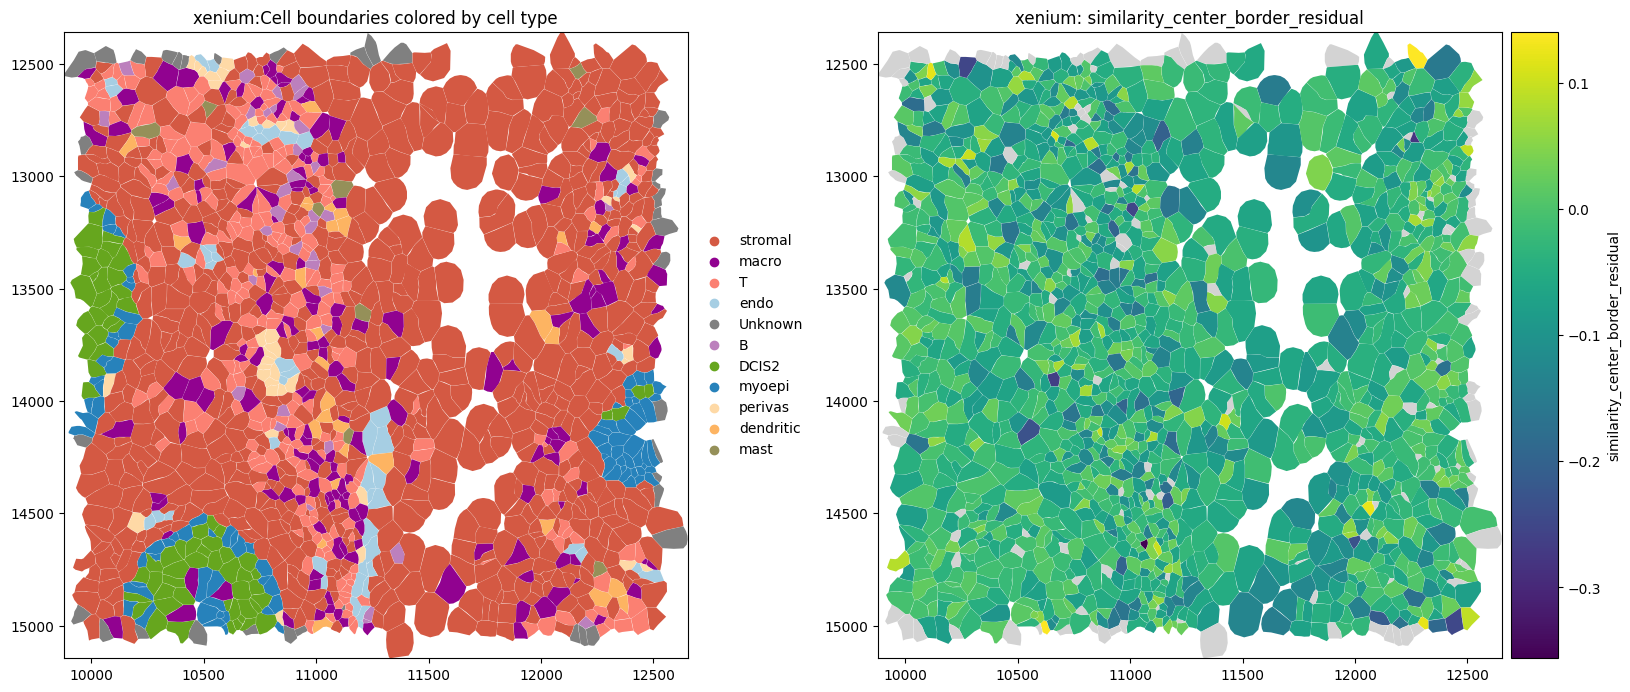

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
#axes = np.atleast_2d(axes)

plot_feature_labels(st.sdata, "xenium", "similarity_center_border_residual", axes)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 138 NaN values in color data. These observations will be colored with the 'na_color'.               


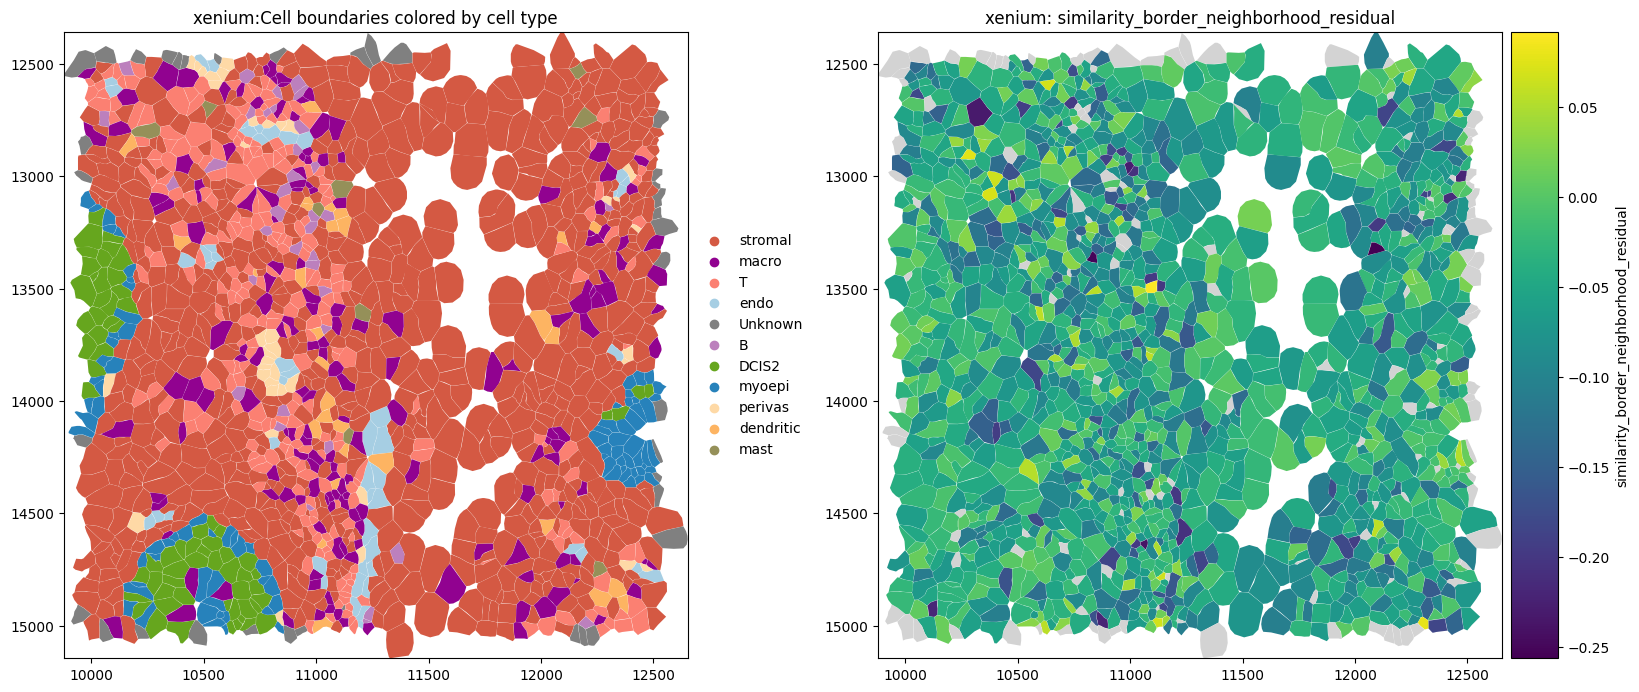

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
plot_feature_labels(sdata, "xenium", "similarity_border_neighborhood_residual", axes)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 138 NaN values in color data. These observations will be colored with the 'na_color'.               


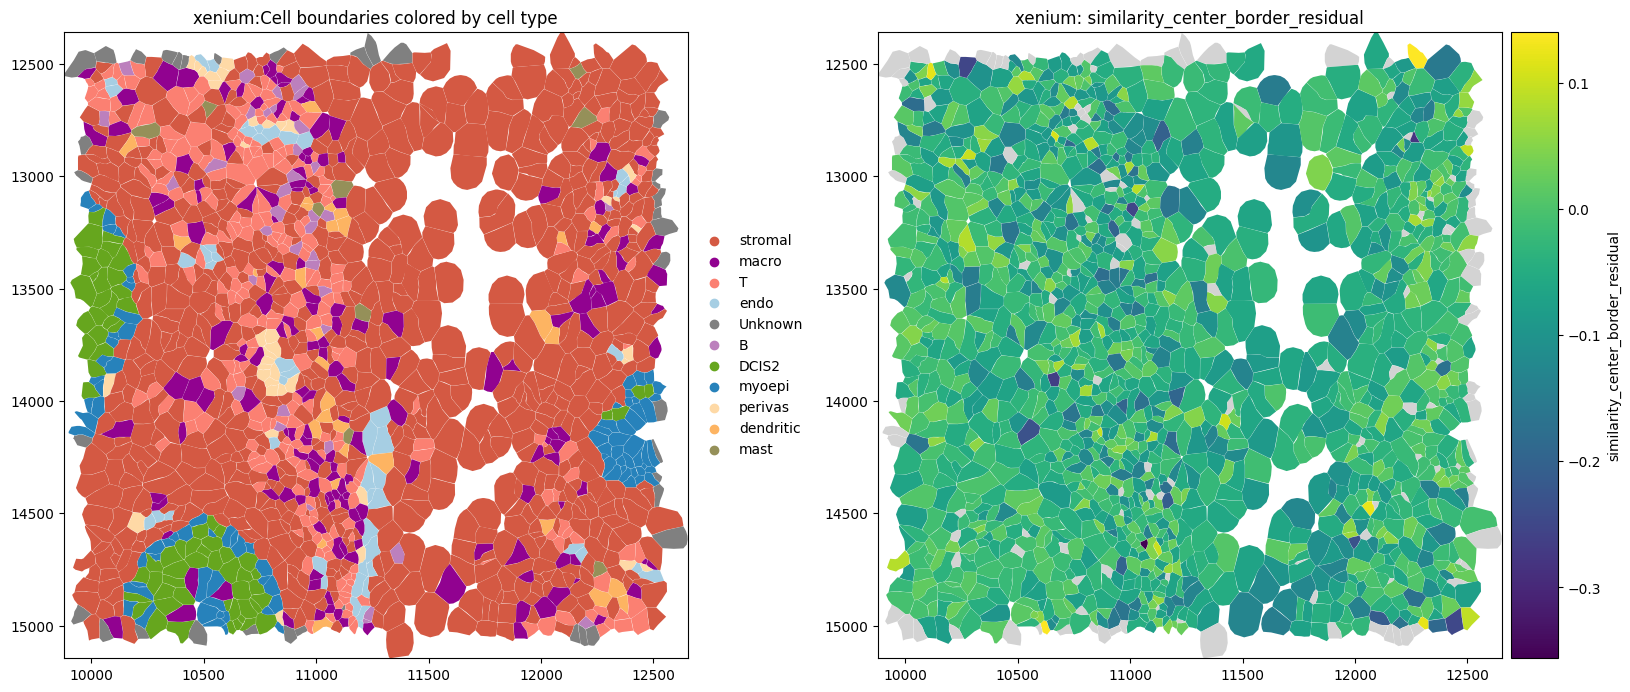

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
plot_feature_labels(sdata, "xenium", "similarity_center_border_residual", axes)

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


WARNING  Found 138 NaN values in color data. These observations will be colored with the 'na_color'.               


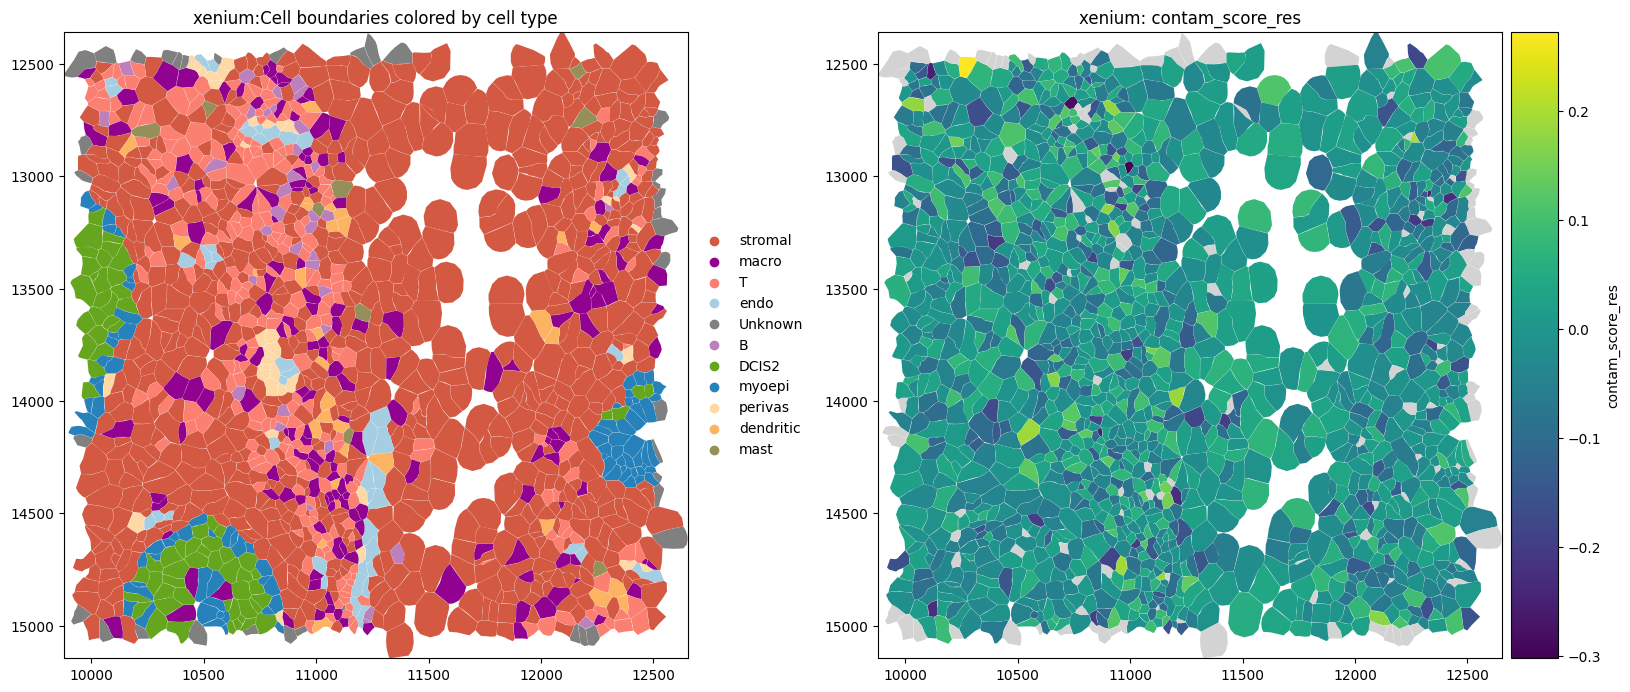

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
plot_feature_labels(sdata, "xenium", "contam_score_res", axes)

In [ ]:
sdata.tables["table"].obs["contam_score_bin"] = sdata.tables["table"].obs["contam_score_res"]>0.1

/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:481: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


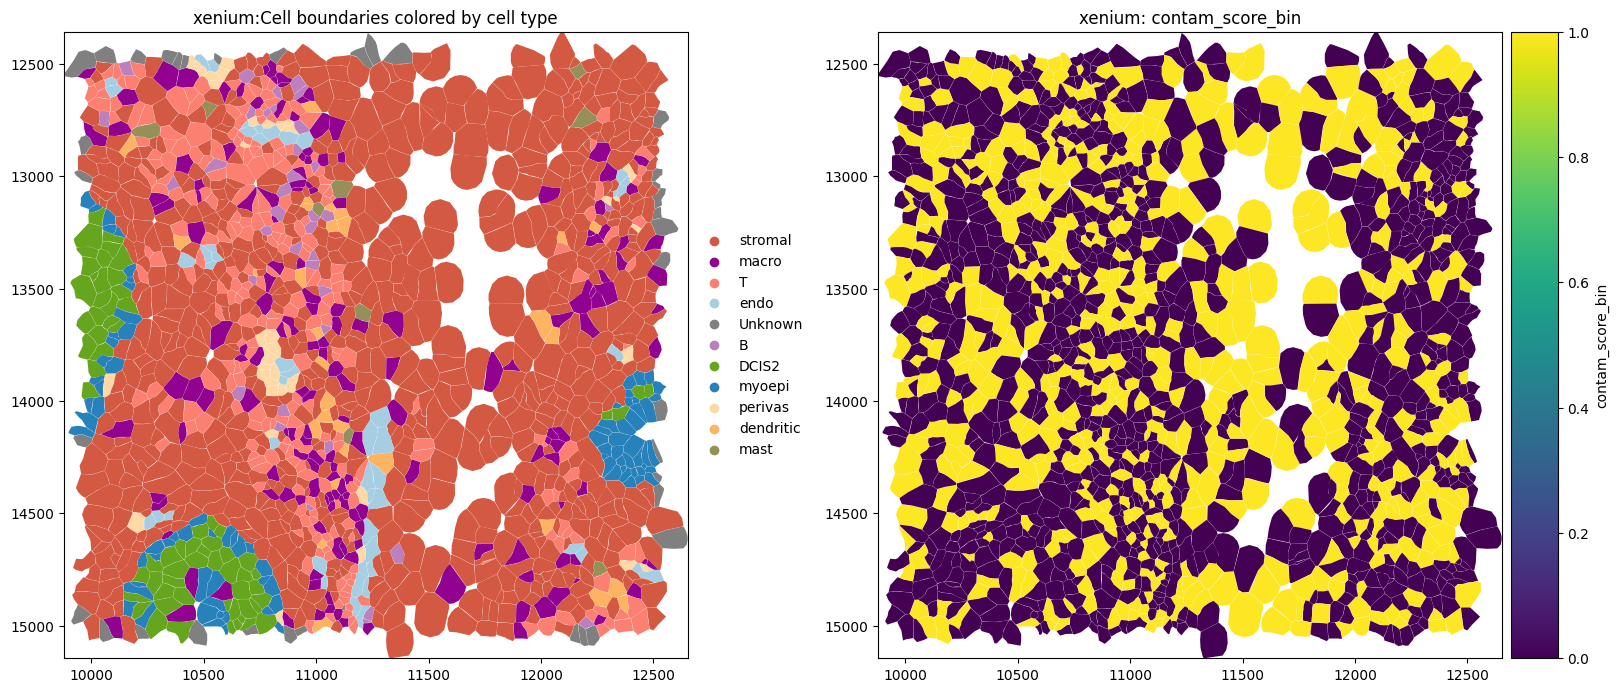

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10), constrained_layout=True)
plot_feature_labels(sdata, "xenium", "contam_score_bin", axes)

In [35]:
feature="similarity_border_neighborhood_residual"

In [36]:
max_value = sdata["table"].obs[feature].sort_values(ascending=False)[9]

/scratch/jobs/50101585/ipykernel_4126666/2058060093.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_value = sdata["table"].obs[feature].sort_values(ascending=False)[9]


In [37]:
cell_id = sdata["table"].obs.loc[sdata["table"].obs[feature]==max_value, "cell_id"]
sdata["table"].obs.loc[sdata["table"].obs[feature]==max_value, :]

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,nucleus_area,region,centroid_x,centroid_y,gene_count,...,contamination_score,center_counts_used,border_counts_used,neighborhood_counts_used,n_genes_used,contam_score_res,transferred_cell_type,pearson_score,transferred_celltype_plot,contam_score_bin
77360,77361,39,0,0,39,17.294844,cell_boundaries,2355.691319,2932.676344,27.0,...,1.087298,34.0,11.0,109.0,75.0,0.055119,T,0.582645,T,True


In [38]:
sdata["table"].obs.loc[sdata["table"].obs[feature]==max_value, ["similarity_center_border", "similarity_center_border_null_mean", "similarity_center_border_residual", "similarity_border_neighborhood", "similarity_border_neighborhood_null_mean", "similarity_border_neighborhood_residual"]]

,similarity_center_border,similarity_center_border_null_mean,similarity_center_border_residual,similarity_border_neighborhood,similarity_border_neighborhood_null_mean,similarity_border_neighborhood_residual
77360,0.400737,0.398676,0.002061,0.32312,0.265939,0.057181


In [39]:
expr_vector = sdata["table"][sdata["table"].obs[feature]==max_value,:].X.toarray()

In [40]:
adata_sub = sdata["table"][sdata["table"].obs[feature] == max_value, :]
expr_vector = np.asarray(adata_sub.X.toarray()).ravel()

expr_vector_nonzero = expr_vector[expr_vector > 0]
genes_nonzero = adata_sub.var_names[expr_vector > 0]
genes = pd.Series(expr_vector_nonzero, index=genes_nonzero).sort_values(ascending=False)[:4].index.tolist()
pd.Series(expr_vector_nonzero, index=genes_nonzero).sort_values(ascending=False)


GZMA        4.0
IL7R        4.0
TRAC        3.0
CD69        2.0
SLAMF1      2.0
KLRB1       2.0
CD4         2.0
LTB         2.0
CD3E        2.0
GPR183      1.0
GATA3       1.0
FAM107B     1.0
CXCR4       1.0
CSF3        1.0
CD3D        1.0
LARS        1.0
MDM2        1.0
PRDM1       1.0
POLR2J3     1.0
PTGDS       1.0
PTPRC       1.0
RUNX1       1.0
RORC        1.0
SERPINB9    1.0
TOMM7       1.0
dtype: float32

In [41]:
# helper function for plotting
def plot_cell_with_nucleus_and_transcripts(
    sdata,
    cid: float | int,
    palette: list,
    title: str,
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding=200,
    genes=None,
    center_layer="nucleus_boundaries",
    outer_layer="cell_boundaries",
):
    # add annotation of this cell to .obs
    sdata["table"].obs["focal_cell"] = sdata["table"].obs["cell_id"] == cid

    # compute x,y of cell and nucleus centroids in µm space
    centroid_x_cell_px = sdata["cell_boundaries"].loc[cid].geometry.centroid.x
    centroid_y_cell_px = sdata["cell_boundaries"].loc[cid].geometry.centroid.y
    centroid_x_cell = centroid_x_cell_px / pix_to_um_scale_factor
    centroid_y_cell = centroid_y_cell_px / pix_to_um_scale_factor

    #nid = sdata["table"].obs.loc[sdata["table"].obs["cell_id"] == cid, "nucleus_id"]
    #centroid_x_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x / pix_to_um_scale_factor
    #centroid_y_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y / pix_to_um_scale_factor

    # add annotation of this cell to .points and build new `PointsModel``
    trans = sdata.points["transcripts"].compute()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans["cell_id"] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")
    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"])
        trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})
    sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points["transcripts"])
    sd.transformations.set_transformation(sdata.points["transcripts_2"], T)

    # zoom in for better visibility
    sdata_cropped = sdata.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[centroid_x_cell - padding, centroid_y_cell - padding],
        max_coordinate=[centroid_x_cell + padding, centroid_y_cell + padding],
        target_coordinate_system="global",
    )

    # plot cell and transcripts of that cell
    axes = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)[1]

    plot = sdata_cropped.pl.render_shapes(
        element=center_layer,
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element=outer_layer,
        color="similarity_border_neighborhood_residual",
        fill_alpha=0.4,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="blue",
    )

    if genes is None:
        plot = plot.pl.render_points(
            "transcripts_2",
            color="focal_cell",
            fill_alpha=0.1,
            size=4.0,
            groups=["focal_cell"],
            palette=["red"],
        )
    else:
        plot = plot.pl.render_points(
            "transcripts",
            color="feature_name",
            fill_alpha=0.1,
            groups=genes,
            size=4.0,
            palette=palette,
        )

    plot.pl.show(
        ax=axes,
        title=title,
        colorbar=True,
    )

    # landmark for cell and nucleus centroid
    axes.scatter([centroid_x_cell], [centroid_y_cell], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)
    #axes.scatter([centroid_x_nucleus], [centroid_y_nucleus], marker="+", s=400, c="black", linewidths=2, zorder=10)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  No table name provided, using 'table' as fallback for color mapping.                                      
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:1123: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_26/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:928: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.

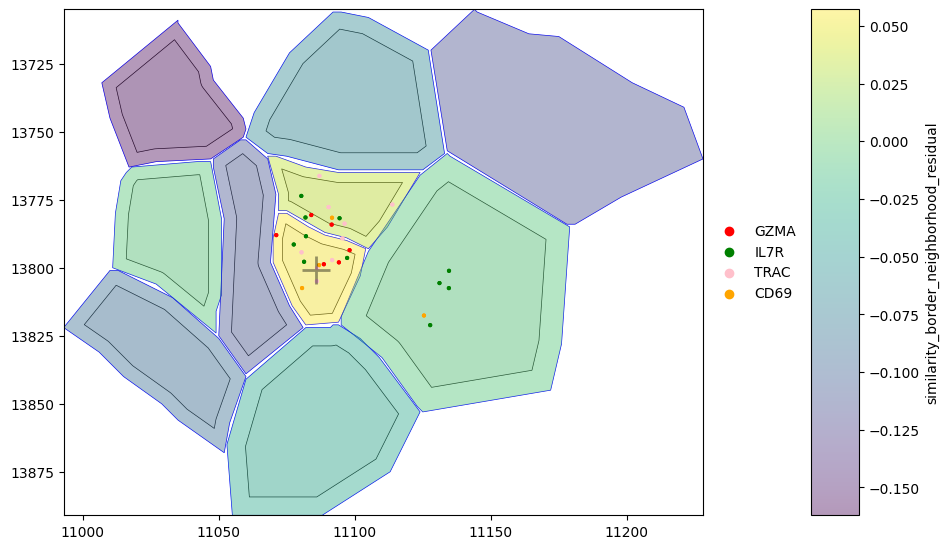

In [42]:
plot_cell_with_nucleus_and_transcripts(sdata, 
                                       cid=cell_id.values[0], 
                                       palette = ["red", "green", "pink", "orange"],
                                       #palette = ["red"],
                                       genes=genes,
                                       title="", 
                                       center_layer="cell_centers", 
                                       #pix_to_um_scale_factor=1, 
                                       padding=50)

In [43]:
sdata_xenium = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr")
sdata_proseg2 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v2_crop.zarr/")
sdata_proseg3 = sd.read_zarr("/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v3_crop.zarr/")

In [44]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_proseg3 = segtraq.SegTraQ(
    sdata_proseg3,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(


In [45]:
st_xenium.filter_control_and_low_quality_transcripts()
st_proseg2.filter_control_and_low_quality_transcripts()
st_proseg3.filter_control_and_low_quality_transcripts(min_qv=None)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:871: RuntimeWarning: Some of the filtered genes (313) also appear in the tables. These genes are: ['HOXD8', 'TACSTD2', 'TOP2A', 'HOOK2', 'KLF5']... If you wish to recompute the expression matrix after filtering, set recompute_expression=True.
  _filter_control_and_low_quality_transcripts(


In [46]:
st_dict = {"xenium": st_xenium, "proseg2": st_proseg2, "proseg3": st_proseg3}

In [47]:
for method, st in st_dict.items():

    _cos_sim = st.rs.null_corrected_center_border_similarity(n_sim=50)

In [48]:
for method, st in st_dict.items():
    st.sdata.tables["table"].obs["contamination"] = st.sdata.tables["table"].obs["similarity_border_neighborhood_residual"] - st.sdata.tables["table"].obs["similarity_center_border_residual"]

In [49]:
def density_plot_feature(sdata_dict, features):
    all_feats = []
    for method, st in sdata_dict.items():
        feat = st.sdata["table"].obs[features]
        tmp = feat.copy()
        tmp["method"] = method
        all_feats.append(tmp)

    df = pd.concat(all_feats, ignore_index=True)
    df["method"] = df["method"].astype(str)

    feature_cols = [c for c in df.columns if c != "method"]

    plt.style.use("dark_background")

    n = len(feature_cols)
    n_cols = min(3, n)
    n_rows = np.ceil(n / n_cols).astype(int)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 2 * n_rows),
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, feat in zip(axes, feature_cols, strict=False):
        sns.kdeplot(data=df, x=feat, hue="method", common_norm=False, palette="Set2", fill=False, ax=ax)

    fig.tight_layout()
    plt.show()

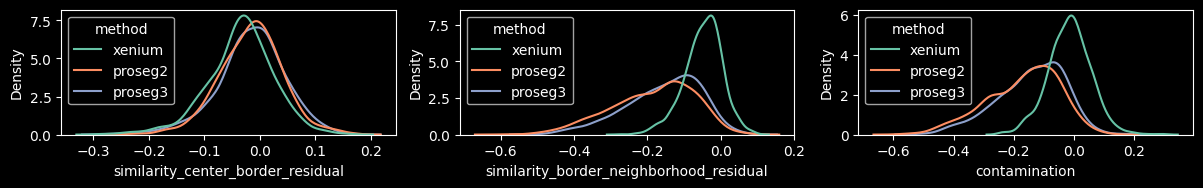

In [50]:
features = ["similarity_center_border_residual", "similarity_border_neighborhood_residual", "contamination"]
density_plot_feature(st_dict, features)

In [51]:
sdata_xenium_ws = sd.read_zarr("../../data/xenium.zarr")
sdata_bidcell_ws = sd.read_zarr("../../data/bidcell.zarr")
sdata_proseg_ws = sd.read_zarr("../../data/proseg2.zarr")

no parent found for <ome_zarr.reader.Label object at 0x7ffea8d4ddd0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffea8e00390>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffea8e01810>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffea961d3d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaa1de950>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaa24a850>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaa2508d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaa22c8d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaa19ab90>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffeaa24ab10>: None


In [52]:
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [53]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata_xenium_ws)
sdata_bidcell = crop(sdata_bidcell_ws)
sdata_proseg = crop(sdata_proseg_ws)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from perfo

In [54]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid"
)
st_bidcell = segtraq.SegTraQ(
    sdata_bidcell,
    images_key="image",
    points_background_id=0,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)
st_proseg = segtraq.SegTraQ(
    sdata_proseg,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1334: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1334: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(


In [55]:
st_dict = {"xenium": st_xenium, "bidcell": st_bidcell, "proseg": st_proseg}

In [56]:
for _, st in st_dict.items():
    st.filter_control_and_low_quality_transcripts(min_qv=20)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:871: RuntimeWarning: Some of the filtered genes (3301) also appear in the tables. These genes are: ['MS4A2', 'UPK1A', 'CUL4A', 'PRM1', 'PPP2R1A']... If you wish to recompute the expression matrix after filtering, set recompute_expression=True.
  _filter_control_and_low_quality_transcripts(


In [57]:
for method, st in st_dict.items():

    _cos_sim = st.rs.null_corrected_center_border_similarity(n_sim=50)
    st.sdata.tables["table"].obs["contamination"] = st.sdata.tables["table"].obs["similarity_border_neighborhood_residual"] - st.sdata.tables["table"].obs["similarity_center_border_residual"]

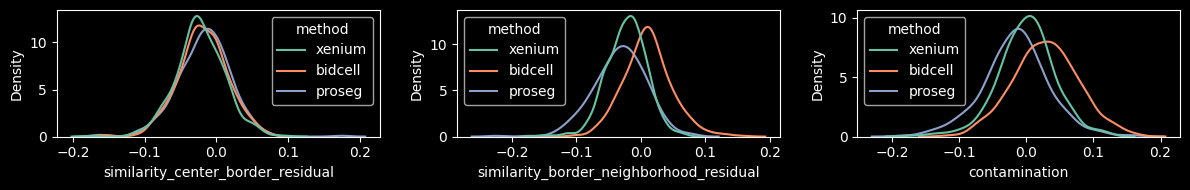

In [58]:
features = ["similarity_center_border_residual", "similarity_border_neighborhood_residual", "contamination"]
density_plot_feature(st_dict, features)